In [1]:
!pwd

/home/oleg/projects/ML/Simpsons


In [2]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=bfb5378d-18a5-468d-a78d-ec9a8dece14e
To: /home/oleg/projects/ML/Simpsons/journey-springfield.zip
100%|████████████████████████████████████████| 546M/546M [00:11<00:00, 46.3MB/s]


In [4]:
!unzip -q /home/oleg/projects/ML/Simpsons/journey-springfield.zip

In [1]:
# Текущая директория
import os
HOME = os.getcwd()
print(HOME)
print('-----------------------')
# Пути
IMAGE_PATH = "/home/oleg/projects/ML/Simpsons/dataset/train/simpsons_dataset"

os.listdir(IMAGE_PATH)

/home/oleg/projects/ML/Simpsons
-----------------------


['comic_book_guy',
 'professor_john_frink',
 'cletus_spuckler',
 'nelson_muntz',
 'gil',
 'edna_krabappel',
 'homer_simpson',
 'snake_jailbird',
 'abraham_grampa_simpson',
 'lisa_simpson',
 'ned_flanders',
 'disco_stu',
 'patty_bouvier',
 'kent_brockman',
 'chief_wiggum',
 'apu_nahasapeemapetilon',
 'moe_szyslak',
 'bart_simpson',
 'groundskeeper_willie',
 'troy_mcclure',
 'waylon_smithers',
 'charles_montgomery_burns',
 'martin_prince',
 'agnes_skinner',
 'carl_carlson',
 'sideshow_mel',
 'principal_skinner',
 'marge_simpson',
 'lenny_leonard',
 'krusty_the_clown',
 'ralph_wiggum',
 'sideshow_bob',
 'otto_mann',
 'fat_tony',
 'maggie_simpson',
 'mayor_quimby',
 'barney_gumble',
 'rainier_wolfcastle',
 'milhouse_van_houten',
 'miss_hoover',
 'lionel_hutz',
 'selma_bouvier']

📊 АНАЛИЗ ДАТАСЕТА:
  abraham_grampa_simpson: 913 файлов
  agnes_skinner: 42 файлов
  apu_nahasapeemapetilon: 623 файлов
  barney_gumble: 106 файлов
  bart_simpson: 1342 файлов
  carl_carlson: 98 файлов
  charles_montgomery_burns: 1193 файлов
  chief_wiggum: 986 файлов
  cletus_spuckler: 47 файлов
  comic_book_guy: 469 файлов
  disco_stu: 8 файлов
  edna_krabappel: 457 файлов
  fat_tony: 27 файлов
  gil: 27 файлов
  groundskeeper_willie: 121 файлов
  homer_simpson: 2246 файлов
  kent_brockman: 498 файлов
  krusty_the_clown: 1206 файлов
  lenny_leonard: 310 файлов
  lionel_hutz: 3 файлов
  lisa_simpson: 1354 файлов
  maggie_simpson: 128 файлов
  marge_simpson: 1291 файлов
  martin_prince: 71 файлов
  mayor_quimby: 246 файлов
  milhouse_van_houten: 1079 файлов
  miss_hoover: 17 файлов
  moe_szyslak: 1452 файлов
  ned_flanders: 1454 файлов
  nelson_muntz: 358 файлов
  otto_mann: 32 файлов
  patty_bouvier: 72 файлов
  principal_skinner: 1194 файлов
  professor_john_frink: 65 файлов
  rainie

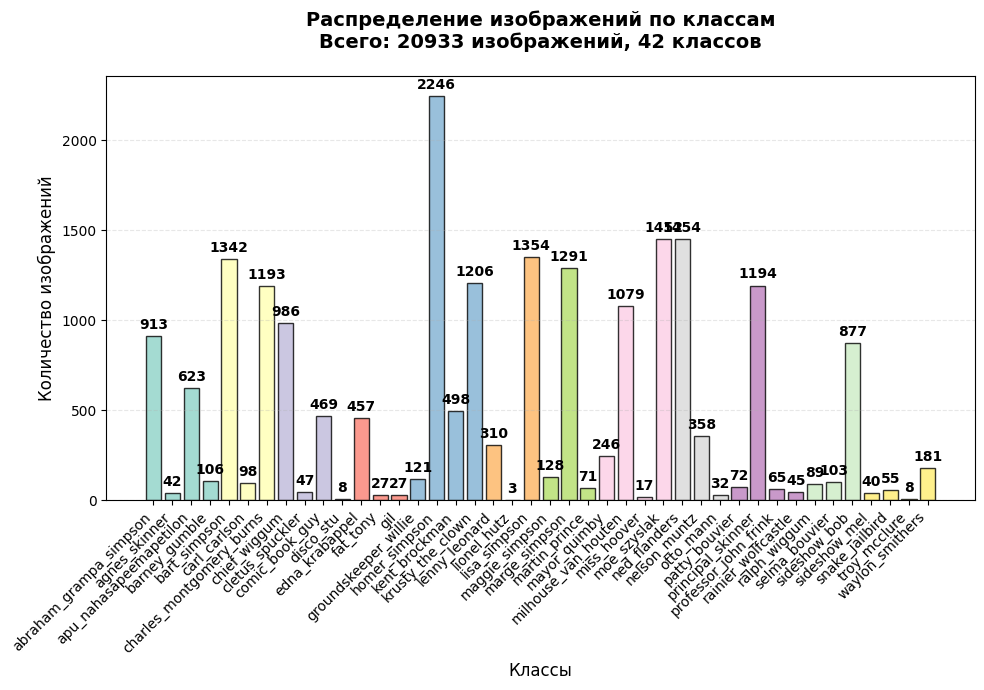

In [2]:
# Простой анализ датасета с визуализацией

import os
import matplotlib.pyplot as plt
import numpy as np

def analyze_dataset_simple(dataset_path):
    """
    Простой анализ датасета с визуализацией
    """
    # Проверяем существование пути
    if not os.path.exists(dataset_path):
        print(f"❌ Ошибка: путь '{dataset_path}' не существует")
        return None
    
    # Получаем список классов
    class_names = [d for d in os.listdir(dataset_path) 
                  if os.path.isdir(os.path.join(dataset_path, d))]
    class_names.sort()
    
    if not class_names:
        print("❌ В датасете не найдено папок с классами")
        return None
    
    # Подсчет файлов
    class_counts = {}
    total_files = 0
    
    print("📊 АНАЛИЗ ДАТАСЕТА:")
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        count = len(image_files)
        class_counts[class_name] = count
        total_files += count
        print(f"  {class_name}: {count} файлов")
    
    print(f"📈 ИТОГО: {total_files} изображений, {len(class_names)} классов")
    
    # Визуализация
    plt.figure(figsize=(10, 7))
    
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    # Создаем диаграмму
    bars = plt.bar(classes, counts, color=plt.cm.Set3(np.linspace(0, 1, len(classes))), 
                   edgecolor='black', alpha=0.8)
    
    # Настройки графика
    plt.title(f'Распределение изображений по классам\nВсего: {total_files} изображений, {len(class_names)} классов', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Классы', fontsize=12)
    plt.ylabel('Количество изображений', fontsize=12)
    
    # Поворачиваем подписи и выравниваем
    plt.xticks(rotation=45, ha='right')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Добавляем сетку для удобства чтения
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Настраиваем отступы
    plt.tight_layout()
    
    plt.show()
    
    return {'class_names': class_names, 'class_counts': class_counts, 'total_files': total_files}

# ИСПОЛЬЗОВАНИЕ:
# Просто вызовите функцию с путем к вашему датасету
result = analyze_dataset_simple(IMAGE_PATH)

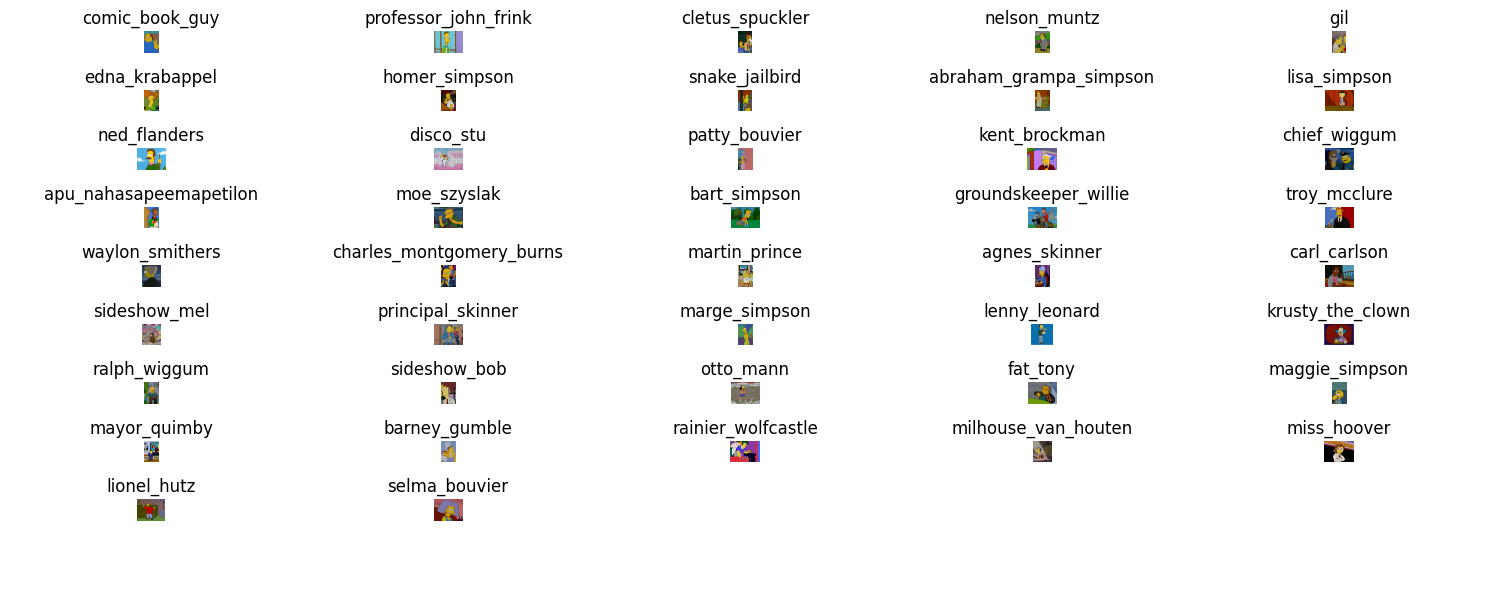

🎲 Показано по 1 случайному изображению из 42 категорий


In [9]:
# Показано по 1 случайному изображению из каждой категорий

from PIL import Image
import os
import matplotlib.pyplot as plt
import random

# Создаем график 2x5
fig, axes = plt.subplots(10, 5, figsize=(15, 6))
axes = axes.ravel()

categories = os.listdir(IMAGE_PATH)
plot_index = 0

for category in categories:
    category_path = os.path.join(IMAGE_PATH, category)
    file_names = os.listdir(category_path)
    
    # Берем 1 случайное изображение из каждой категории
    if file_names:
        random_file = random.choice(file_names)
        img_path = os.path.join(category_path, random_file)
        img = Image.open(img_path)
        
        axes[plot_index].imshow(img)
        axes[plot_index].set_title(f"{category}", fontsize=12)
        axes[plot_index].axis('off')
        plot_index += 1

# Скрываем лишние subplot'ы
for i in range(plot_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"🎲 Показано по 1 случайному изображению из {plot_index} категорий")

In [7]:
# МЕТКИ INTEGER

# САМЫЙ ПРОСТОЙ ВАРИАНТ - integer labels

import tensorflow as tf

#from tensorflow.keras.applications.resnet50 import preprocess_input        # импорт для resnet50
from tensorflow.keras.applications.efficientnet import preprocess_input     # импорт для efficientnet
#from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

import numpy as np
import matplotlib.pyplot as plt

height, width = 224, 224
batch_size=32

print("🔄 СОЗДАЕМ ПАЙПЛАЙН...")

# Загрузка данных (хорошо!)
train_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

validation_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='validation', 
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

# Проверка формата (хорошо!)
images, labels = next(iter(train_data_raw))
print(f"Labels shape: {labels.shape}")  # (32,) - integer
print(f"Labels: {labels.numpy()[:15]}")  # [0, 1, 0, 2, 1]

class_names = train_data_raw.class_names
num_classes = len(class_names)
print(f"🏷️ Классы: {class_names}")

# Аугментация (хорошо!)
data_augmentation = tf.keras.Sequential([
    # ГЕОМЕТРИЧЕСКИЕ ТРАНСФОРМАЦИИ
    tf.keras.layers.RandomFlip("horizontal"),
    #f.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05), # увеличить угол
    tf.keras.layers.RandomZoom(0.1), # увеличить зум
    tf.keras.layers.RandomTranslation(0.1, 0.1),  # сдвиг по X и Y
    # ЦВЕТОВЫЕ ТРАНСФОРМАЦИИ  
    #tf.keras.layers.RandomContrast(0.1),
    #tf.keras.layers.RandomBrightness(0.1),
    # ШУМЫ И ИСКАЖЕНИЯ
    #tf.keras.layers.GaussianNoise(0.1),
    
    
])

#print("🔧 СОЗДАЕМ ПРОСТОЙ ПАЙПЛАЙН...")

'''
# Проепроцессин для RESNET
def preprocess_and_augment(image, label, training=False):
    """Preprocess + аугментация если training=True"""
    image = preprocess_input(tf.cast(image, tf.float32))
    if training:
        image = data_augmentation(image, training=True)
    return image, label
'''


# Проепроцессин для EfficientNet
def preprocess_and_augment(image, label, training=False):
    """Правильный препроцессинг для EfficientNet"""
    image = tf.cast(image, tf.float32)
    #image = preprocess_input(image)  # ✅ Должен нормализовать в [0, 1] или [-1, 1]
    if training:
        image = data_augmentation(image, training=True)
    return image, label

# Финальные datasets
train_data = (
    train_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=True),
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()  # ✅ ДОБАВИТЬ: кэширование ускорит обучение    
    .prefetch(tf.data.AUTOTUNE)
)

validation_data = (
    validation_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=False), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()  # ✅ ДОБАВИТЬ: кэширование ускорит обучение    
    .prefetch(tf.data.AUTOTUNE)
)

# Убедимся что препроцессинг работает правильно
print("🔍 Проверка препроцессинга:")
for images, labels in train_data.take(1):
    print(f"Shape: {images.shape}")
    print(f"Data range: {tf.reduce_min(images):.3f} to {tf.reduce_max(images):.3f}")
    print(f"Mean: {tf.reduce_mean(images):.3f}")
    break

print("✅ Пайплайн создан!")

🔄 СОЗДАЕМ ПАЙПЛАЙН...
Found 20935 files belonging to 42 classes.
Using 16748 files for training.
Found 20935 files belonging to 42 classes.
Using 4187 files for validation.
Labels shape: (32,)
Labels: [27  4 32  4 25  4 27  7  6 28 37 41 17 41  4]
🏷️ Классы: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'cletus_spuckler', 'comic_book_guy', 'disco_stu', 'edna_krabappel', 'fat_tony', 'gil', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lionel_hutz', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'martin_prince', 'mayor_quimby', 'milhouse_van_houten', 'miss_hoover', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'otto_mann', 'patty_bouvier', 'principal_skinner', 'professor_john_frink', 'rainier_wolfcastle', 'ralph_wiggum', 'selma_bouvier', 'sideshow_bob', 'sideshow_mel', 'snake_jailbird', 'troy_mcclure', 'waylon_smithers

2025-11-12 11:28:45.405253: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


🎯 Расчет весов классов из тренировочных данных...


2025-11-12 09:57:24.598983: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


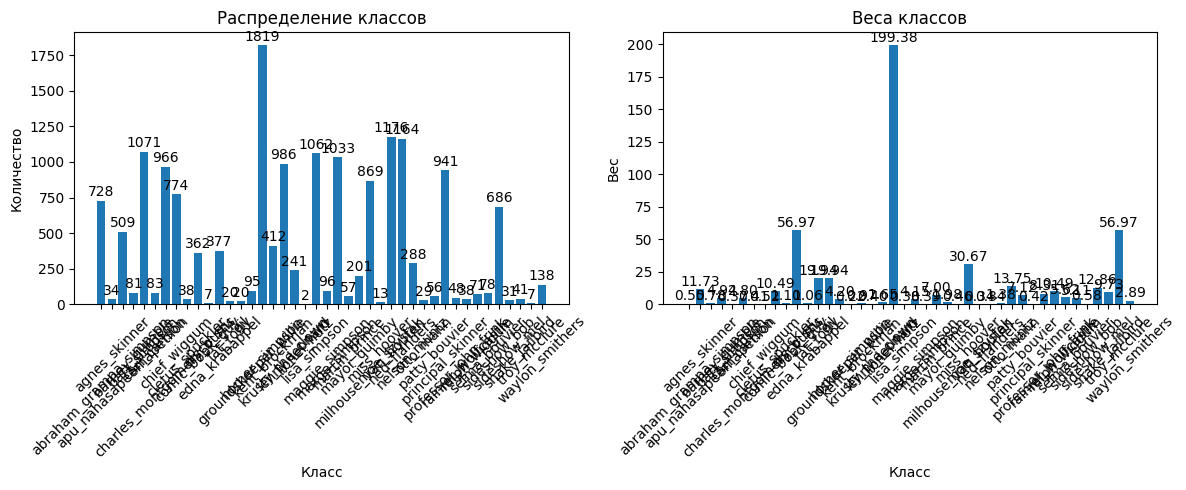

📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ:
--------------------------------------------------
abraham_grampa_simpson |  728 | вес: 0.55
agnes_skinner   |   34 | вес: 11.73
apu_nahasapeemapetilon |  509 | вес: 0.78
barney_gumble   |   81 | вес: 4.92
bart_simpson    | 1071 | вес: 0.37
carl_carlson    |   83 | вес: 4.80
charles_montgomery_burns |  966 | вес: 0.41
chief_wiggum    |  774 | вес: 0.52
cletus_spuckler |   38 | вес: 10.49
comic_book_guy  |  362 | вес: 1.10
disco_stu       |    7 | вес: 56.97
edna_krabappel  |  377 | вес: 1.06
fat_tony        |   20 | вес: 19.94
gil             |   20 | вес: 19.94
groundskeeper_willie |   95 | вес: 4.20
homer_simpson   | 1819 | вес: 0.22
kent_brockman   |  412 | вес: 0.97
krusty_the_clown |  986 | вес: 0.40
lenny_leonard   |  241 | вес: 1.65
lionel_hutz     |    2 | вес: 199.38
lisa_simpson    | 1062 | вес: 0.38
maggie_simpson  |   96 | вес: 4.15
marge_simpson   | 1033 | вес: 0.39
martin_prince   |   57 | вес: 7.00
mayor_quimby    |  201 | вес: 1.98
milhouse_van_

In [13]:
# Рассчитывает веса классов из tf.data.Dataset

def get_class_weights_from_dataset(dataset, class_names):
    """
    Рассчитывает веса классов из tf.data.Dataset
    """
    # Собираем все метки
    all_labels = []
    for images, labels in dataset:
        all_labels.extend(labels.numpy())
    
    y_train = np.array(all_labels)
    
    # Расчет весов
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    
    weights_dict = dict(enumerate(class_weights))
    
    # Визуализация
    plt.figure(figsize=(12, 5))
    
    # График 1: Распределение классов
    plt.subplot(1, 2, 1)
    unique, counts = np.unique(y_train, return_counts=True)
    bars = plt.bar(range(len(unique)), counts)
    plt.title('Распределение классов')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.xticks(range(len(unique)), [class_names[i] for i in unique], rotation=45)
    
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                str(count), ha='center', va='bottom')
    
    # График 2: Веса классов
    plt.subplot(1, 2, 2)
    bars = plt.bar(weights_dict.keys(), weights_dict.values())
    plt.title('Веса классов')
    plt.xlabel('Класс')
    plt.ylabel('Вес')
    plt.xticks(range(len(unique)), [class_names[i] for i in unique], rotation=45)
    
    for bar, weight in zip(bars, weights_dict.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{weight:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Вывод информации
    print("📊 РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
    print("-" * 50)
    for i, class_name in enumerate(class_names):
        count = counts[i] if i < len(counts) else 0
        weight = weights_dict.get(i, 0)
        print(f"{class_name:15} | {count:4} | вес: {weight:.2f}")
    
    return weights_dict

# ИСПОЛЬЗОВАНИЕ:
print("🎯 Расчет весов классов из тренировочных данных...")
class_weights = get_class_weights_from_dataset(train_data_raw, class_names)

✅ Модель создана для 42 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,321,290 (85.15 MB)

 Trainable params: 1,984,298 (7.57 MB)

...

505/524 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2406 - loss: 2.9817

2025-11-12 10:29:43.466365: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24328', 16 bytes spill stores, 16 bytes spill loads

2025-11-12 10:29:46.311789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-12 10:29:46.480135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-12 10:29:47.173907: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-12 10:29:47.368713: E external/local_xla/xla/s

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2438 - loss: 2.9660

2025-11-12 10:30:03.588443: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 10:30:03.782239: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4302', 28 bytes spill stores, 28 bytes spill loads

2025-11-12 10:30:03.939418: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4302', 8 bytes spill stores, 8 bytes spill loads

2025-11-12 10:30:04.036350: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4302', 56 byte


Epoch 1: val_accuracy improved from None to 0.59470, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.3332 - loss: 2.5375 - val_accuracy: 0.5947 - val_loss: 1.5068 - learning_rate: 0.0010
Epoch 2/50
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4847 - loss: 1.9033
Epoch 2: val_accuracy improved from 0.59470 to 0.66826, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.5070 - loss: 1.8136 - val_accuracy: 0.6683 - val_loss: 1.2432 - learning_rate: 0.0010
Epoch 3/50
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5554 - loss: 1.6011
Epoch 3: val_accuracy improved from 0.66826 to 0.70050, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5724 - loss: 1.5347 - val_accuracy: 0.7005 - val_loss: 1.1199 - learning_rate: 0.0010

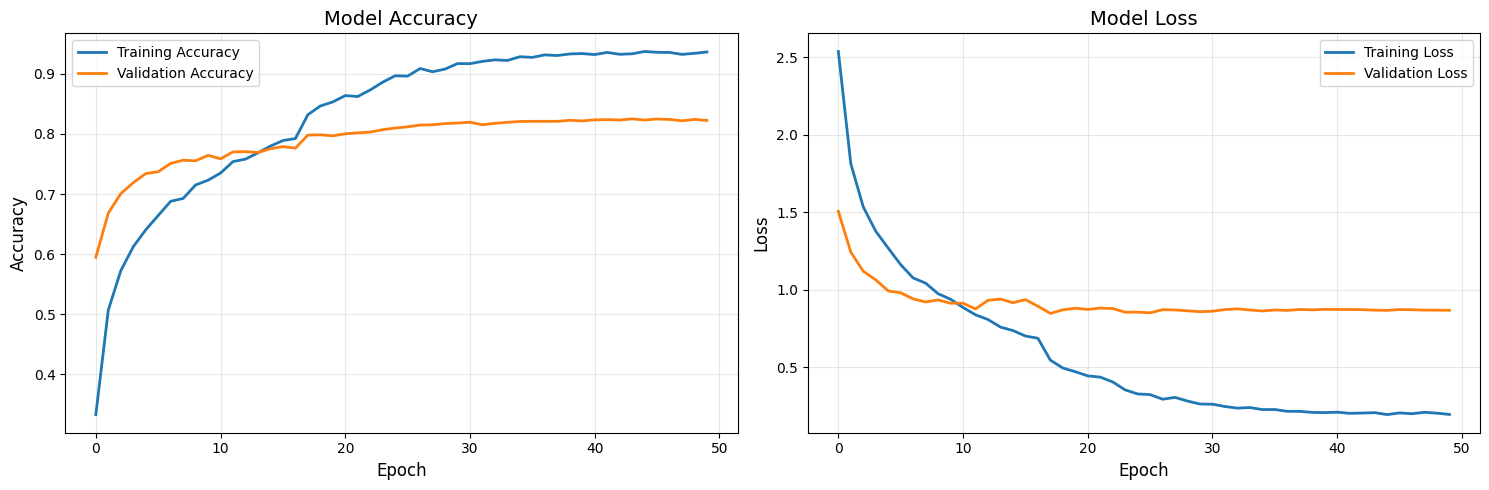

In [5]:
# MIDDLE



model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_' # {_middle_}

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2


# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса

# 3. Functional API с training=False
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

x = layers.GlobalAveragePooling2D()(x)  # Сжатие пространственных признаков
x = layers.BatchNormalization()(x)      # Стабилизация начальных признаков

x = layers.Dense(1024, activation='relu')(x)        # Максимальная емкость для сложных паттернов
x = layers.BatchNormalization()(x)                  # Контроль распределения в высокоразмерном пространстве
x = layers.Dropout(0.4)(x)                          # Сильная регуляризация против переобучения сложных признаков

# x = layers.Dense(768, activation='relu')(x)         # Плавное уменьшение размерности
# x = layers.BatchNormalization()(x)                  # Стабилизация промежуточных представлений
# x = layers.Dropout(0.35)(x)                         # Умеренная регуляризация

x = layers.Dense(512, activation='relu')(x)         # Компактное представление признаков
x = layers.BatchNormalization()(x)                  # Подготовка к финальной классификации
x = layers.Dropout(0.3)(x)                          # Легкая регуляризация

x = layers.Dense(256, activation='relu')(x)         # Финальная адаптация признаков
x = layers.Dropout(0.2)(x)                          # Минимальная регуляризация перед выходом


# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1,
    #class_weight=class_weights,
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print("\n📊 ОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 42 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 42)             │        21,546 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,015,946 (80.17 MB)

 Trainable params: 681,002 (2.60 MB)

...

Epoch 1/50


2025-11-12 10:51:57.557300: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 10:51:57.557411: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 10:51:57.557424: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 10:51:58.009524: I external/l

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3399 - loss: 2.8077

2025-11-12 10:52:43.998944: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 10:52:44.420359: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4269', 8 bytes spill stores, 8 bytes spill loads

2025-11-12 10:52:44.456105: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4269', 4 bytes spill stores, 4 bytes spill loads




Epoch 1: val_accuracy improved from None to 0.66898, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.4455 - loss: 2.2322 - val_accuracy: 0.6690 - val_loss: 1.2531 - learning_rate: 0.0010
Epoch 2/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6036 - loss: 1.4505
Epoch 2: val_accuracy improved from 0.66898 to 0.72176, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.6159 - loss: 1.3971 - val_accuracy: 0.7218 - val_loss: 1.0561 - learning_rate: 0.0010
Epoch 3/50
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6698 - loss: 1.1653
Epoch 3: val_accuracy improved from 0.72176 to 0.73227, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.6700 - loss: 1.1490 - val_accuracy: 0.7323 - val_loss: 0.9942 - learning_rate: 0.0010


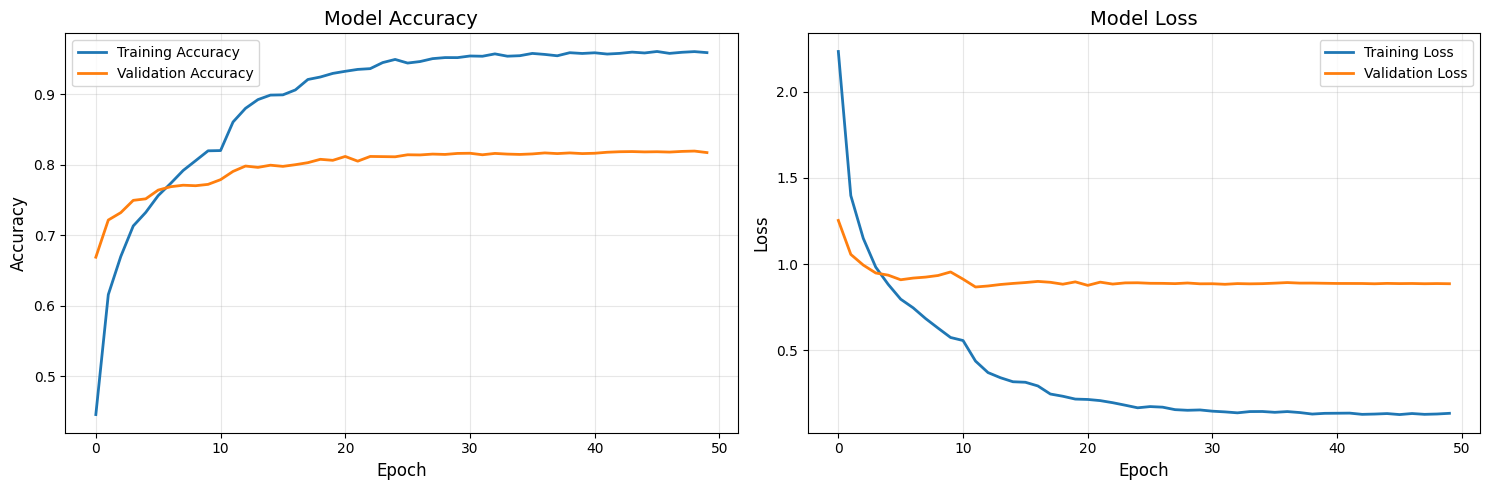

In [6]:
# MIDDLE



model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_2_' # {_middle_}

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2


# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса

# 3. Functional API с training=False
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

x = layers.GlobalAveragePooling2D()(x)  # Сжатие пространственных признаков
x = layers.BatchNormalization()(x)      # Стабилизация начальных признаков

# x = layers.Dense(1024, activation='relu')(x)        # Максимальная емкость для сложных паттернов
# x = layers.BatchNormalization()(x)                  # Контроль распределения в высокоразмерном пространстве
# x = layers.Dropout(0.4)(x)                          # Сильная регуляризация против переобучения сложных признаков

# x = layers.Dense(768, activation='relu')(x)         # Плавное уменьшение размерности
# x = layers.BatchNormalization()(x)                  # Стабилизация промежуточных представлений
# x = layers.Dropout(0.35)(x)                         # Умеренная регуляризация

x = layers.Dense(512, activation='relu')(x)         # Компактное представление признаков
x = layers.BatchNormalization()(x)                  # Подготовка к финальной классификации
x = layers.Dropout(0.3)(x)                          # Легкая регуляризация

# x = layers.Dense(256, activation='relu')(x)         # Финальная адаптация признаков
# x = layers.Dropout(0.2)(x)                          # Минимальная регуляризация перед выходом


# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1,
    #class_weight=class_weights,
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print("\n📊 ОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 42 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,703,754 (78.98 MB)

 Trainable params: 369,322 (1.41 MB)

...

Epoch 1/50


2025-11-12 11:31:59.783139: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:31:59.783225: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:31:59.783254: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:31:59.783262: I external/l

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2155 - loss: 3.5637

2025-11-12 11:32:45.472358: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4288', 20 bytes spill stores, 20 bytes spill loads

2025-11-12 11:32:53.877760: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:32:54.202708: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4281', 16 bytes spill stores, 16 bytes spill loads




Epoch 1: val_accuracy improved from None to 0.59064, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - accuracy: 0.3034 - loss: 3.0890 - val_accuracy: 0.5906 - val_loss: 2.0818 - learning_rate: 0.0010
Epoch 2/50
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4541 - loss: 2.4739
Epoch 2: val_accuracy improved from 0.59064 to 0.64844, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.4721 - loss: 2.3972 - val_accuracy: 0.6484 - val_loss: 1.7711 - learning_rate: 0.0010
Epoch 3/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5141 - loss: 2.2157
Epoch 3: val_accuracy improved from 0.64844 to 0.66969, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.5285 - loss: 2.1637 - val_accuracy: 0.6697 - val_loss: 1.6700 - learning_rate: 0.0010


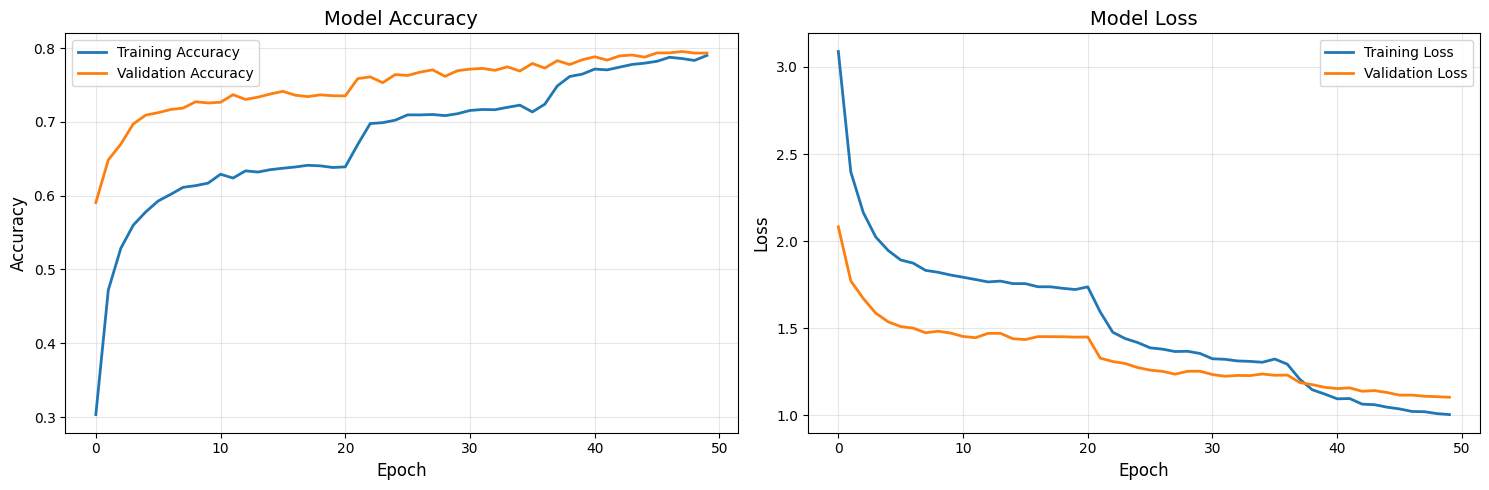

In [9]:
# MIDDLE

from tensorflow.keras import regularizers

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_2_' # {_middle_}

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2


# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса

# 3. Functional API с training=False
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

x = layers.GlobalAveragePooling2D()(x)  # Сжатие пространственных признаков
x = layers.BatchNormalization()(x)      # Стабилизация начальных признаков

# x = layers.Dense(1024, activation='relu')(x)        # Максимальная емкость для сложных паттернов
# x = layers.BatchNormalization()(x)                  # Контроль распределения в высокоразмерном пространстве
# x = layers.Dropout(0.4)(x)                          # Сильная регуляризация против переобучения сложных признаков

# x = layers.Dense(768, activation='relu')(x)         # Плавное уменьшение размерности
# x = layers.BatchNormalization()(x)                  # Стабилизация промежуточных представлений
# x = layers.Dropout(0.35)(x)                         # Умеренная регуляризация

x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)         # Компактное представление признаков
x = layers.BatchNormalization()(x)                  # Подготовка к финальной классификации
x = layers.Dropout(0.4)(x)                          # Легкая регуляризация

x = layers.Dense(128, activation='relu')(x)         # Финальная адаптация признаков
x = layers.Dropout(0.3)(x)                          # Минимальная регуляризация перед выходом


# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1,
    #class_weight=class_weights,
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print("\n📊 ОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




In [ ]:
# 2. Optuna (Bayesian Optimization)

import optuna
from optuna.integration import TFKerasPruningCallback
import tensorflow as tf
#--------------------------------------------------------------------------------------------------------------------
from tensorflow.keras.applications import ResNet50, EfficientNetV2S, EfficientNetV2B0, EfficientNetB0, EfficientNetV2M, EfficientNetV2L
# from tensorflow.keras.applications import (
#     ResNet50,
#     EfficientNetV2S, EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, 
#     EfficientNetV2B3, EfficientNetV2L, EfficientNetV2M, EfficientNetV2XL
# )
#from convnext import ConvNeXtTiny, ConvNeXtSmall, ConvNeXtBase, ConvNeXtLarge, ConvNeXtXLarge

#-----------------------------------------------------------------------------------------------------------------------
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout, BatchNormalization, Activation, Concatenate, Add)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
tf.get_logger().setLevel('ERROR')

# 🔧 СЛОВАРЬ MODELS:
MODELS = {
    # EfficientNetV2 Family (рекомендуется)
    # 'EfficientNetV2B0': EfficientNetV2B0,
    # 'EfficientNetV2B1': EfficientNetV2B1, 
    # 'EfficientNetV2B2': EfficientNetV2B2,
    # 'EfficientNetV2B3': EfficientNetV2B3,
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M, 
    'EfficientNetV2L': EfficientNetV2L,
    # 'EfficientNetV2XL': EfficientNetV2XL,
   
    # ResNet Family  
    'ResNet50': ResNet50,
    # 'ResNeXt50': ResNeXt50,

    #   print("⚠️ ConvNeXt не установлен. Для установки: pip install convnext-tensorflow")
    # ConvNeXt Family
    # 'ConvNeXtTiny': ConvNeXtTiny,
    # 'ConvNeXtSmall': ConvNeXtSmall,
    # 'ConvNeXtBase': ConvNeXtBase, 
    # 'ConvNeXtLarge': ConvNeXtLarge,
    # 'ConvNeXtXLarge': ConvNeXtXLarge,
}


# =============================================================================
# 🔧 ПРЕДВАРИТЕЛЬНЫЕ НАСТРОЙКИ (ДОЛЖНЫ БЫТЬ ОПРЕДЕЛЕНЫ!)
# =============================================================================

# 🎯 ЗАДАЙТЕ ЭТИ ПЕРЕМЕННЫЕ ПЕРЕД ЗАПУСКОМ:

model_name = 'EfficientNetV2S'  # Или 'EfficientNetV2S' и т.д.
n_trials = 20

height, width = 224, 224


def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5, activation='relu'):
    """Оптимизированный residual block для небольших датасетов"""
    
    # Основной путь
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    x = Dropout(dropout_rate)(x)
    
    return x

def create_optuna_model(trial):
    """Создает модель с параметрами которые предлагает Optuna"""
    
    # 1. Optuna предлагает параметры для тестирования
    #units_1 = trial.suggest_categorical('units_1', [256, 512])
    units_2 = trial.suggest_categorical('units_2', [256, 1024]) 
    units_3 = trial.suggest_categorical('units_3', [64, 256])
    #dropout_1 = trial.suggest_categorical('dropout_1', [0.6, 0.7, 0.8])
    dropout_2 = trial.suggest_categorical('dropout_2', [0.4, 0.5, 0.6, 0.7])
    dropout_3 = trial.suggest_categorical('dropout_3', [0.2, 0.3, 0.4])
    l2_reg = trial.suggest_categorical('l2_reg', [1e-5, 1e-5, 1e-4, 1e-3])
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5,1e-5, 1e-4, 1e-3])
    activation = trial.suggest_categorical('activation', ['relu', 'elu', 'selu'])

    # 2. ВХОД И БАЗОВАЯ МОДЕЛЬ
    inputs = tf.keras.Input(shape=(height, width, 3))
    
    base_model = MODELS[model_name](
        weights='imagenet',
        include_top=False,
        input_shape=(height, width, 3)
    )
    base_model.trainable = False
    x = base_model(inputs, training=False)
    '''
    # 98-40
    # 3. КЛАССИФИКАТОР С ДВОЙНЫМ POOLING
    gap = GlobalAveragePooling2D()(x)
    gmp = GlobalMaxPooling2D()(x)
    x = Concatenate()([gap, gmp])
    x = BatchNormalization()(x)
    # 4. РЕЗИДУАЛЬНЫЕ БЛОКИ (ПЕРЕДАЕМ ВСЕ ПАРАМЕТРЫ)
    #x = residual_block(x, units_1, dropout_1, l2_reg, activation)
    x = residual_block(x, units_2, dropout_2, l2_reg, activation) 
    x = residual_block(x, units_3, dropout_3, l2_reg, activation)
    '''
    # 3. КЛАССИФИКАТОР С ДВОЙНЫМ POOLING
    #gap = GlobalAveragePooling2D()(x)
    #x = GlobalMaxPooling2D()(x)
    x = GlobalAveragePooling2D()(x)
    
    #x = BatchNormalization()(x)
    # 4. РЕЗИДУАЛЬНЫЕ БЛОКИ (ПЕРЕДАЕМ ВСЕ ПАРАМЕТРЫ)
    #x = residual_block(x, units_1, dropout_1, l2_reg, activation)
    x = residual_block(x, units_2, dropout_2, l2_reg, activation) 
    x = residual_block(x, units_3, dropout_3, l2_reg, activation)
#==================================================================================================
    # x = layers.GlobalAveragePooling2D()(x)
    # x = layers.BatchNormalization()(x)  # ⬅️ Добавляем BatchNorm
    # x = layers.Dense(units_1, activation)(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.Dropout(dropout_2)(x)
    # x = layers.Dense(units_1, activation)(x) 
    # x = layers.BatchNormalization()(x)
    # x = layers.Dropout(dropout_3)(x)
#==================================================================================================
    
    # 5. ВЫХОДНОЙ СЛОЙ
    outputs = Dense(num_classes, activation='softmax')(x)

    
    # 6. СОБИРАЕМ И КОМПИЛИРУЕМ МОДЕЛЬ
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# =============================================================================
# 🎯 ФУНКЦИЯ OPTIMIZATION
# =============================================================================

def objective(trial):
    """Целевая функция для Optuna"""
    
    model = create_optuna_model(trial)
    
    history = model.fit(
        train_data,
        epochs=15,
        validation_data=validation_data,
        verbose=1,
        callbacks=[
            EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),
            TFKerasPruningCallback(trial, 'val_accuracy')
        ]
    )
    
    best_val_accuracy = max(history.history['val_accuracy'])
    return best_val_accuracy

# =============================================================================
# 🚀 ЗАПУСК ОПТИМИЗАЦИИ
# =============================================================================

print("🚀 ЗАПУСК OPTUNA OPTIMIZATION...")

study = optuna.create_study(
    direction='maximize',
    study_name='EfficientNetV2S_MINI_4',
    storage='sqlite:///my_optuna_study.db',
    load_if_exists=True
)

study.optimize(objective, n_trials=n_trials)

print("\n🎯 OPTUNA ОПТИМИЗАЦИЯ ЗАВЕРШЕНА!")

# РЕЗУЛЬТАТЫ
print(f"\n🏆 ЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"  Accuracy: {study.best_value:.4f}")
print("  Параметры:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# ФИНАЛЬНАЯ МОДЕЛЬ
print("\n🔧 СОЗДАЕМ ФИНАЛЬНУЮ НЕ ОБУЧЕННУЮ МОДЕЛЬ...")
best_model = create_optuna_model(study.best_trial)
best_model.summary()

# Сохраняем текущую модель
best_model.save('model_optuna_best_params.keras')
print("💾 Модель сохранена как 'model_optuna_best_params.keras'")

# ВСТРОЕННЫЕ ВИЗУАЛИЗАЦИИ OPTUNA
print("\n📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ...")

# 1. График оптимизации
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# 2. Важность параметров
fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

# 3. Параллельные координаты
fig3 = optuna.visualization.plot_parallel_coordinate(study)
fig3.show()

# 4. Распределение параметров
fig4 = optuna.visualization.plot_contour(study)
fig4.show()

# 5. Сравнение распределений
fig5 = optuna.visualization.plot_slice(study)
fig5.show()

# 6. Timeline оптимизации
fig6 = optuna.visualization.plot_timeline(study)
fig6.show()

print("\n📊 ДЛЯ ПРОСМОТРА РЕЗУЛЬТАТОВ:")
print("В терминале выполни: optuna-dashboard sqlite:///my_optuna_study.db")

🚀 ЗАПУСК OPTUNA OPTIMIZATION...


[I 2025-11-12 11:48:42,810] A new study created in RDB with name: EfficientNetV2S_MINI_4


Epoch 1/15


2025-11-12 11:48:55.323597: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:48:55.323685: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:48:55.323703: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-12 11:48:55.323713: I external/l

524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2563 - loss: 3.0436

...

Epoch 1/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.3035 - loss: 2.7552 - val_accuracy: 0.5971 - val_loss: 1.7387
Epoch 2/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.4518 - loss: 2.1144 - val_accuracy: 0.6489 - val_loss: 1.4938
Epoch 3/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4958 - loss: 1.9545 - val_accuracy: 0.6644 - val_loss: 1.4095
Epoch 4/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5176 - loss: 1.8587 - val_accuracy: 0.6828 - val_loss: 1.3407
Epoch 5/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5373 - loss: 1.7913 - val_accuracy: 0.6938 - val_loss: 1.2839
Epoch 6/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.5525 - loss: 1.7492 - val_accuracy: 0.7055 - val_loss: 1.2551
Epoch 7/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5623 - loss: 1.7035 - val_accuracy: 0.7148 - val_loss: 1.2257
Epoch 8/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.5738 - loss: 1.6800 - 

[I 2025-11-12 12:48:18,394] Trial 11 finished with value: 0.745402455329895 and parameters: {'units_2': 256, 'units_3': 64, 'dropout_2': 0.7, 'dropout_3': 0.3, 'l2_reg': 0.0001, 'learning_rate': 0.001, 'activation': 'elu'}. Best is trial 0 with value: 0.751850962638855.


Epoch 1/15
524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0246 - loss: 4.2690

[I 2025-11-12 12:49:26,211] Trial 12 pruned. Trial was pruned at epoch 0.


Epoch 1/15


In [ ]:
cd /home/oleg/projects/ML/Simpsons/

mlflow ui --backend-store-uri sqlite:///my_optuna_study.db --host 0.0.0.0 --port 5000

In [ ]:
# Обучаем финальную модель дольше
# Полный код для вашего случая
import datetime
import os
from tensorflow.keras.callbacks import TensorBoard

best_model = tf.keras.models.load_model('model_optuna_best_params.keras')
# ОЦЕНКА НЕ ОБУЧЕННОЙ МОДЕЛИ
print(f"\n📊 ОЦЕНКА НЕ ОБУЧЕННОЙ  МОДЕЛИ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results[0], val_results[1]
print(f"✅ Результаты обученной модели:")
print(f"   - Validation Accuracy: {val_accuracy:.4f}")
print(f"   - Validation Loss: {val_loss:.4f}")

# 1. Создаем папку для логов
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

# 2. Создаем callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=False,  # Можно отключить для экономии места
    update_freq='epoch',
    profile_batch=0
)


final_history = best_model.fit(
    train_data,
    epochs=70,
    validation_data=validation_data,
    class_weight=class_weights,  # ← вот это если надо функция баланса классов class_weights
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(f'best_model-optuna_callback.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.3, verbose=1),
        tensorboard_callback
    ],
    verbose=1
)


# ОЦЕНКА ОБУЧЕННОЙ МОДЕЛИ
print(f"\n📊 ОЦЕНКА ОБУЧЕННОЙ МОДЕЛИ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results[0], val_results[1]
print(f"✅ Результаты обученной модели:")
print(f"   - Validation Accuracy: {val_accuracy:.4f}")
print(f"   - Validation Loss: {val_loss:.4f}")

# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# Сохраняем модель
best_model.save('best_optuna_model.keras')
print("💾 Модель сохранена как 'best_optuna_model.keras'")

'''
loaded_model.summary()

# 5. После обучения запускаем TensorBoard
print("\n🎯 Для просмотра TensorBoard выполните:")
print("!tensorboard --logdir logs/fit") tensorboard --logdir=logs/fit
print("И откройте http://localhost:6006/")
'''
